# 03 — Inferencia de Sentimiento en Datos Scrapeados

Aplica el modelo E0 (`cardiffnlp/twitter-roberta-base-sentiment`) sobre las 4 campañas
para comparabilidad cross-campaña. Adicionalmente, para `españa_2023` (tweets en español)
se aplica también **RoBERTuito** (`pysentimiento/robertuito-sentiment-analysis`), modelo
entrenado específicamente sobre Twitter en español.

| Campaña | Idioma | Modelos aplicados |
|---|---|---|
| `brexit_2016` | EN | E0 |
| `trump_2016` | EN | E0 |
| `trump_2024` | EN | E0 |
| `españa_2023` | ES | E0 + RoBERTuito |

**Prerequisito**: haber ejecutado `01_preprocessing.ipynb` y `02_sentiment_tweeteval.ipynb`.

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q',
        'transformers', 'datasets', 'torch', 'google-cloud-storage',
        'pyarrow', 'matplotlib', 'seaborn', 'scipy',
        'pysentimiento'], check=True)
    SA = '/content/service-account.json'
    assert os.path.exists(SA), 'Sube service-account.json a /content/'
    print('Setup OK')
else:
    SA = '/Users/jimenamillamoreno/Desktop/TFM/TFM/scrapper/service-account.json'
    print('Local OK')

Setup OK


In [2]:
import io, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import pearsonr

import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from google.cloud import storage
from google.oauth2 import service_account

device = 0 if torch.cuda.is_available() else -1
print(f'Device: {"cuda" if device == 0 else "cpu"}')

os.makedirs('figures', exist_ok=True)

_creds  = service_account.Credentials.from_service_account_file(SA)
_gcli   = storage.Client(credentials=_creds)

PROCESSED_BUCKET = 'tfm-twitter-processed'
CURATED_BUCKET   = 'tfm-twitter-curated'
CAMPAIGNS        = ['brexit_2016', 'trump_2016', 'trump_2024', 'españa_2023']
LABEL_MAP        = {0: 'negativo', 1: 'neutro', 2: 'positivo'}
COLORS           = {'negativo': '#e74c3c', 'neutro': '#95a5a6', 'positivo': '#2ecc71'}

KEY_EVENTS = {
    'brexit_2016': [
        ('2016-05-16', 'Informe HM Treasury\n(impacto económico Brexit)'),
        ('2016-06-16', 'Asesinato Jo Cox'),
        ('2016-06-23', 'Día del referéndum'),
        ('2016-06-24', 'Resultado: Leave gana\nDimisión Cameron'),
    ],
    'trump_2016': [
        ('2016-09-26', '1er debate\nTrump-Clinton'),
        ('2016-10-07', 'Grabación\n"Access Hollywood"'),
        ('2016-10-09', '2o debate'),
        ('2016-10-28', 'Carta Comey/FBI\n(emails Hillary)'),
        ('2016-11-08', 'Día de elecciones'),
        ('2016-11-09', 'Trump gana'),
    ],
    'trump_2024': [
        ('2024-09-10', 'Debate Trump-Harris'),
        ('2024-09-15', '2o intento asesinato\n(Ryan Routh)'),
        ('2024-10-01', 'Debate VP\nWalz vs Vance'),
        ('2024-10-05', 'Huracán Milton'),
        ('2024-11-05', 'Día de elecciones'),
        ('2024-11-06', 'Trump gana'),
    ],
    'españa_2023': [
        ('2023-07-07', 'Inicio oficial campaña\n(Chupinazo San Fermín)'),
        ('2023-07-10', 'Debate Feijóo-Sánchez\nAtresMedia'),
        ('2023-07-21', 'Fin de campaña electoral'),
        ('2023-07-22', 'Jornada de reflexión'),
        ('2023-07-23', 'Elecciones 23J'),
        ('2023-07-24', 'PP gana sin mayoría\nBloqueo gobierno'),
    ],
}

print('Imports OK')

Device: cuda
Imports OK


## 1. Carga de datos procesados

In [3]:
dfs = {}
for campaign in CAMPAIGNS:
    buf = io.BytesIO(_gcli.bucket(PROCESSED_BUCKET).blob(f'scraped/{campaign}.parquet').download_as_bytes())
    df  = pd.read_parquet(buf)
    df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
    df['date']       = df['created_at'].dt.date
    df['campaign']   = campaign
    dfs[campaign]    = df
    print(f'{campaign}: {len(df):,} tweets | text_nulls={df["text"].isna().sum()} | {df["date"].min()} → {df["date"].max()}')

print('\nColumnas ejemplo:', list(dfs['brexit_2016'].columns))

brexit_2016: 15,046 tweets | text_nulls=0 | 2016-04-15 → 2016-06-29
trump_2016: 27,776 tweets | text_nulls=0 | 2016-09-01 → 2016-11-14
trump_2024: 33,957 tweets | text_nulls=0 | 2024-09-01 → 2024-11-10
españa_2023: 36,383 tweets | text_nulls=0 | 2023-06-20 → 2023-07-24

Columnas ejemplo: ['id', 'text', 'created_at', 'lang', 'like_count', 'retweet_count', 'reply_count', 'campaign', 'task', 'target', 'query_slug', 'author_username', 'is_retweet', 'hashtags', 'text_clean', 'date']


## 2. Carga de modelos

- **E0** (`cardiffnlp/twitter-roberta-base-sentiment`): aplicado a las 4 campañas — permite comparación homogénea
- **RoBERTuito** (`pysentimiento/robertuito-sentiment-analysis`): aplicado solo a `españa_2023` — entrenado sobre 500M tweets en español

In [4]:
# --- E0: Cardiff RoBERTa (inglés) ---
MODEL_ID = 'cardiffnlp/twitter-roberta-base-sentiment'
sentiment_pipe = pipeline(
    'text-classification',
    model=MODEL_ID,
    device=device,
    truncation=True,
    max_length=128,
    batch_size=64,
)
MODEL_LABEL_MAP = {'LABEL_0': 'negativo', 'LABEL_1': 'neutro', 'LABEL_2': 'positivo'}

# Test rápido E0
test = sentiment_pipe(['I love this!', 'This is terrible.', 'Just a normal day.'])
for txt, r in zip(['love', 'terrible', 'normal'], test):
    print(f'  E0 "{txt}" → {MODEL_LABEL_MAP[r["label"]]} ({r["score"]:.3f})')

# --- RoBERTuito: español ---
from pysentimiento import create_analyzer
robertuito_analyzer = create_analyzer(task='sentiment', lang='es')
ROBERTUITO_LABEL_MAP = {'POS': 'positivo', 'NEG': 'negativo', 'NEU': 'neutro'}

# Test rápido RoBERTuito
test_es = ['Me encanta esto', 'Esto es terrible', 'Un día normal']
for txt in test_es:
    res = robertuito_analyzer.predict(txt)
    label = ROBERTUITO_LABEL_MAP.get(res.output, res.output)
    score = max(res.probas.values())
    print(f'  RoBERTuito "{txt}" → {label} ({score:.3f})')

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  499MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

  RoBERTuito "Me encanta esto" → positivo (0.903)
  RoBERTuito "Esto es terrible" → negativo (0.904)
  RoBERTuito "Un día normal" → neutro (0.568)


El error ese es de que no tengo el token de HuggingFace en Colab, pero como los modelos son públicos, da igual.

## 3. Inferencia por campaña

Usamos `text_clean` (BERTweet-normalizado) para consistencia con el entrenamiento.
La inferencia completa (~115k tweets) tarda ~8 min en GPU T4.

In [5]:
for campaign, df in dfs.items():
    print(f'\nInferencia {campaign} ({len(df):,} tweets)...')
    texts   = df['text_clean'].fillna('').tolist()
    results = sentiment_pipe(texts)
    df['sentiment']       = [MODEL_LABEL_MAP[r['label']] for r in results]
    df['sentiment_score'] = [r['score'] for r in results]
    df['polarity'] = df.apply(
        lambda row: row['sentiment_score']  if row['sentiment'] == 'positivo'
                    else -row['sentiment_score'] if row['sentiment'] == 'negativo'
                    else 0.0, axis=1
    )
    print(f'  E0: {df["sentiment"].value_counts().to_dict()}')

# RoBERTuito adicional para España 2023
print('\nRoBERTuito sobre españa_2023...')
df_es   = dfs['españa_2023']
texts_es = df_es['text'].fillna('').tolist()  # texto original en español (sin normalización BERTweet)
rob_results = [robertuito_analyzer.predict(t) for t in texts_es]
df_es['sentiment_robertuito']       = [ROBERTUITO_LABEL_MAP.get(r.output, r.output) for r in rob_results]
df_es['sentiment_score_robertuito'] = [max(r.probas.values()) for r in rob_results]
df_es['polarity_robertuito'] = df_es.apply(
    lambda row: row['sentiment_score_robertuito']  if row['sentiment_robertuito'] == 'positivo'
                else -row['sentiment_score_robertuito'] if row['sentiment_robertuito'] == 'negativo'
                else 0.0, axis=1
)
print(f'  RoBERTuito: {df_es["sentiment_robertuito"].value_counts().to_dict()}')
print('\nInferencia completada.')


Inferencia brexit_2016 (15,046 tweets)...
  E0: {'neutro': 7287, 'negativo': 4781, 'positivo': 2978}

Inferencia trump_2016 (27,776 tweets)...
  E0: {'negativo': 11979, 'neutro': 10100, 'positivo': 5697}

Inferencia trump_2024 (33,957 tweets)...
  E0: {'neutro': 13805, 'negativo': 11090, 'positivo': 9062}

Inferencia españa_2023 (36,383 tweets)...
  E0: {'neutro': 34707, 'positivo': 1371, 'negativo': 305}

RoBERTuito sobre españa_2023...
  RoBERTuito: {'negativo': 18107, 'neutro': 15423, 'positivo': 2853}

Inferencia completada.


In [6]:
# Guardar resultados E0 (todas las campañas)
for campaign, df in dfs.items():
    cols = ['id', 'text', 'text_clean', 'created_at', 'date', 'campaign',
            'like_count', 'retweet_count', 'reply_count',
            'sentiment', 'sentiment_score', 'polarity']
    save_cols = [c for c in cols if c in df.columns]
    buf = io.BytesIO()
    df[save_cols].to_parquet(buf, index=False)
    buf.seek(0)
    _gcli.bucket(CURATED_BUCKET).blob(f'results/sentiment_scraped/{campaign}.parquet').upload_from_file(
        buf, content_type='application/octet-stream')
    print(f'E0 guardado: gs://{CURATED_BUCKET}/results/sentiment_scraped/{campaign}.parquet')

# Guardar resultados RoBERTuito (solo españa_2023, columnas adicionales)
df_es = dfs['españa_2023']
rob_cols = ['id', 'text', 'text_clean', 'created_at', 'date', 'campaign',
            'like_count', 'retweet_count', 'reply_count',
            'sentiment', 'sentiment_score', 'polarity',
            'sentiment_robertuito', 'sentiment_score_robertuito', 'polarity_robertuito']
rob_save_cols = [c for c in rob_cols if c in df_es.columns]
buf = io.BytesIO()
df_es[rob_save_cols].to_parquet(buf, index=False)
buf.seek(0)
_gcli.bucket(CURATED_BUCKET).blob('results/sentiment_scraped/españa_2023_dual.parquet').upload_from_file(
    buf, content_type='application/octet-stream')
print(f'Dual guardado: gs://{CURATED_BUCKET}/results/sentiment_scraped/españa_2023_dual.parquet')

E0 guardado: gs://tfm-twitter-curated/results/sentiment_scraped/brexit_2016.parquet
E0 guardado: gs://tfm-twitter-curated/results/sentiment_scraped/trump_2016.parquet
E0 guardado: gs://tfm-twitter-curated/results/sentiment_scraped/trump_2024.parquet
E0 guardado: gs://tfm-twitter-curated/results/sentiment_scraped/españa_2023.parquet
Dual guardado: gs://tfm-twitter-curated/results/sentiment_scraped/españa_2023_dual.parquet


## 3b. España 2023: comparativa E0 vs RoBERTuito

E0 (inglés) vs RoBERTuito (español nativo). Esperamos diferencias en neutrales y en confianza media.

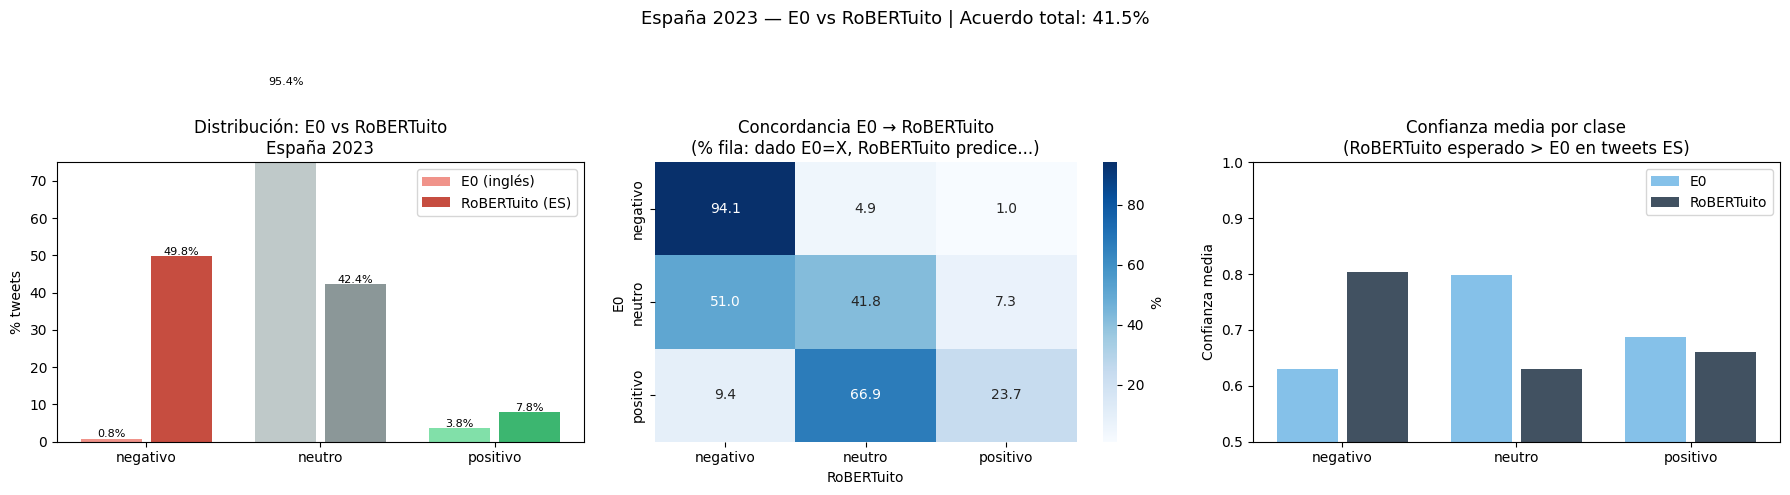


Acuerdo total E0 ↔ RoBERTuito: 41.5%

Tabla cruzada absoluta:
sentiment_robertuito  negativo  neutro  positivo
sentiment                                       
negativo                   287      15         3
neutro                   17691   14491      2525
positivo                   129     917       325


In [7]:
df_es = dfs['españa_2023']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución comparada
ax = axes[0]
order = ['negativo', 'neutro', 'positivo']
e0_pcts  = [df_es['sentiment'].eq(s).mean()*100 for s in order]
rob_pcts = [df_es['sentiment_robertuito'].eq(s).mean()*100 for s in order]
x = np.arange(len(order))
ax.bar(x - 0.2, e0_pcts,  0.35, label='E0 (inglés)',    color=['#e74c3c','#95a5a6','#2ecc71'], alpha=0.6)
ax.bar(x + 0.2, rob_pcts, 0.35, label='RoBERTuito (ES)', color=['#c0392b','#7f8c8d','#27ae60'], alpha=0.9)
for i, (e, r) in enumerate(zip(e0_pcts, rob_pcts)):
    ax.text(i - 0.2, e + 0.3, f'{e:.1f}%', ha='center', fontsize=8)
    ax.text(i + 0.2, r + 0.3, f'{r:.1f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('% tweets'); ax.set_ylim(0, 75)
ax.set_title('Distribución: E0 vs RoBERTuito\nEspaña 2023')
ax.legend()

# Concordancia entre modelos (matriz de confusión cruzada)
ax2 = axes[1]
cross = pd.crosstab(df_es['sentiment'], df_es['sentiment_robertuito'], normalize='index') * 100
cross = cross.reindex(index=order, columns=order, fill_value=0)
sns.heatmap(cross, annot=True, fmt='.1f', cmap='Blues', ax=ax2,
            cbar_kws={'label': '%'})
ax2.set_xlabel('RoBERTuito'); ax2.set_ylabel('E0')
ax2.set_title('Concordancia E0 → RoBERTuito\n(% fila: dado E0=X, RoBERTuito predice...)')

# Confianza media por modelo
ax3 = axes[2]
conf_e0  = [df_es[df_es['sentiment']==s]['sentiment_score'].mean() for s in order]
conf_rob = [df_es[df_es['sentiment_robertuito']==s]['sentiment_score_robertuito'].mean() for s in order]
ax3.bar(x - 0.2, conf_e0,  0.35, label='E0',         color='#3498db', alpha=0.6)
ax3.bar(x + 0.2, conf_rob, 0.35, label='RoBERTuito', color='#2c3e50', alpha=0.9)
ax3.set_xticks(x); ax3.set_xticklabels(order)
ax3.set_ylabel('Confianza media'); ax3.set_ylim(0.5, 1.0)
ax3.set_title('Confianza media por clase\n(RoBERTuito esperado > E0 en tweets ES)')
ax3.legend()

# Acuerdo total
agreement = (df_es['sentiment'] == df_es['sentiment_robertuito']).mean() * 100
plt.suptitle(f'España 2023 — E0 vs RoBERTuito | Acuerdo total: {agreement:.1f}%', fontsize=13)
plt.tight_layout()
plt.savefig('figures/03_espana_e0_vs_robertuito.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAcuerdo total E0 ↔ RoBERTuito: {agreement:.1f}%')
print('\nTabla cruzada absoluta:')
print(pd.crosstab(df_es['sentiment'], df_es['sentiment_robertuito']))

## 4. Distribución de sentimiento por campaña

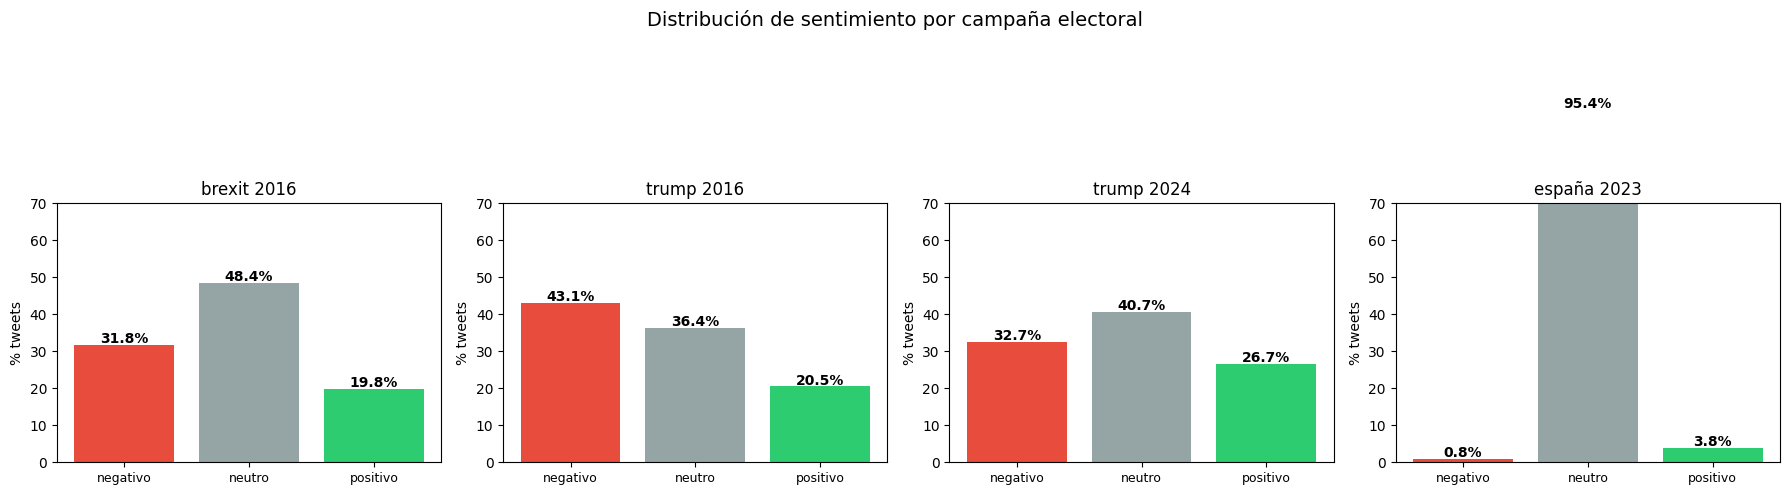


Resumen (%):
sentiment    negativo  neutro  positivo
brexit_2016      31.8    48.4      19.8
trump_2016       43.1    36.4      20.5
trump_2024       32.7    40.7      26.7
españa_2023       0.8    95.4       3.8


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (campaign, df) in zip(axes, dfs.items()):
    counts = df['sentiment'].value_counts(normalize=True) * 100
    order  = ['negativo', 'neutro', 'positivo']
    vals   = [counts.get(s, 0) for s in order]
    bars   = ax.bar(order, vals, color=[COLORS[s] for s in order])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(campaign.replace('_', ' '), fontsize=12)
    ax.set_ylim(0, 70)
    ax.set_ylabel('% tweets')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Distribución de sentimiento por campaña electoral', fontsize=14)
plt.tight_layout()
plt.savefig('figures/03_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
summary = pd.DataFrame({
    c: dfs[c]['sentiment'].value_counts(normalize=True).mul(100).round(1)
    for c in CAMPAIGNS
}).T
print('\nResumen (%):')
print(summary[['negativo', 'neutro', 'positivo']])

## 5. Timeline de sentimiento con eventos clave

Media móvil de 3 días del score de polaridad (-1=muy negativo, +1=muy positivo).

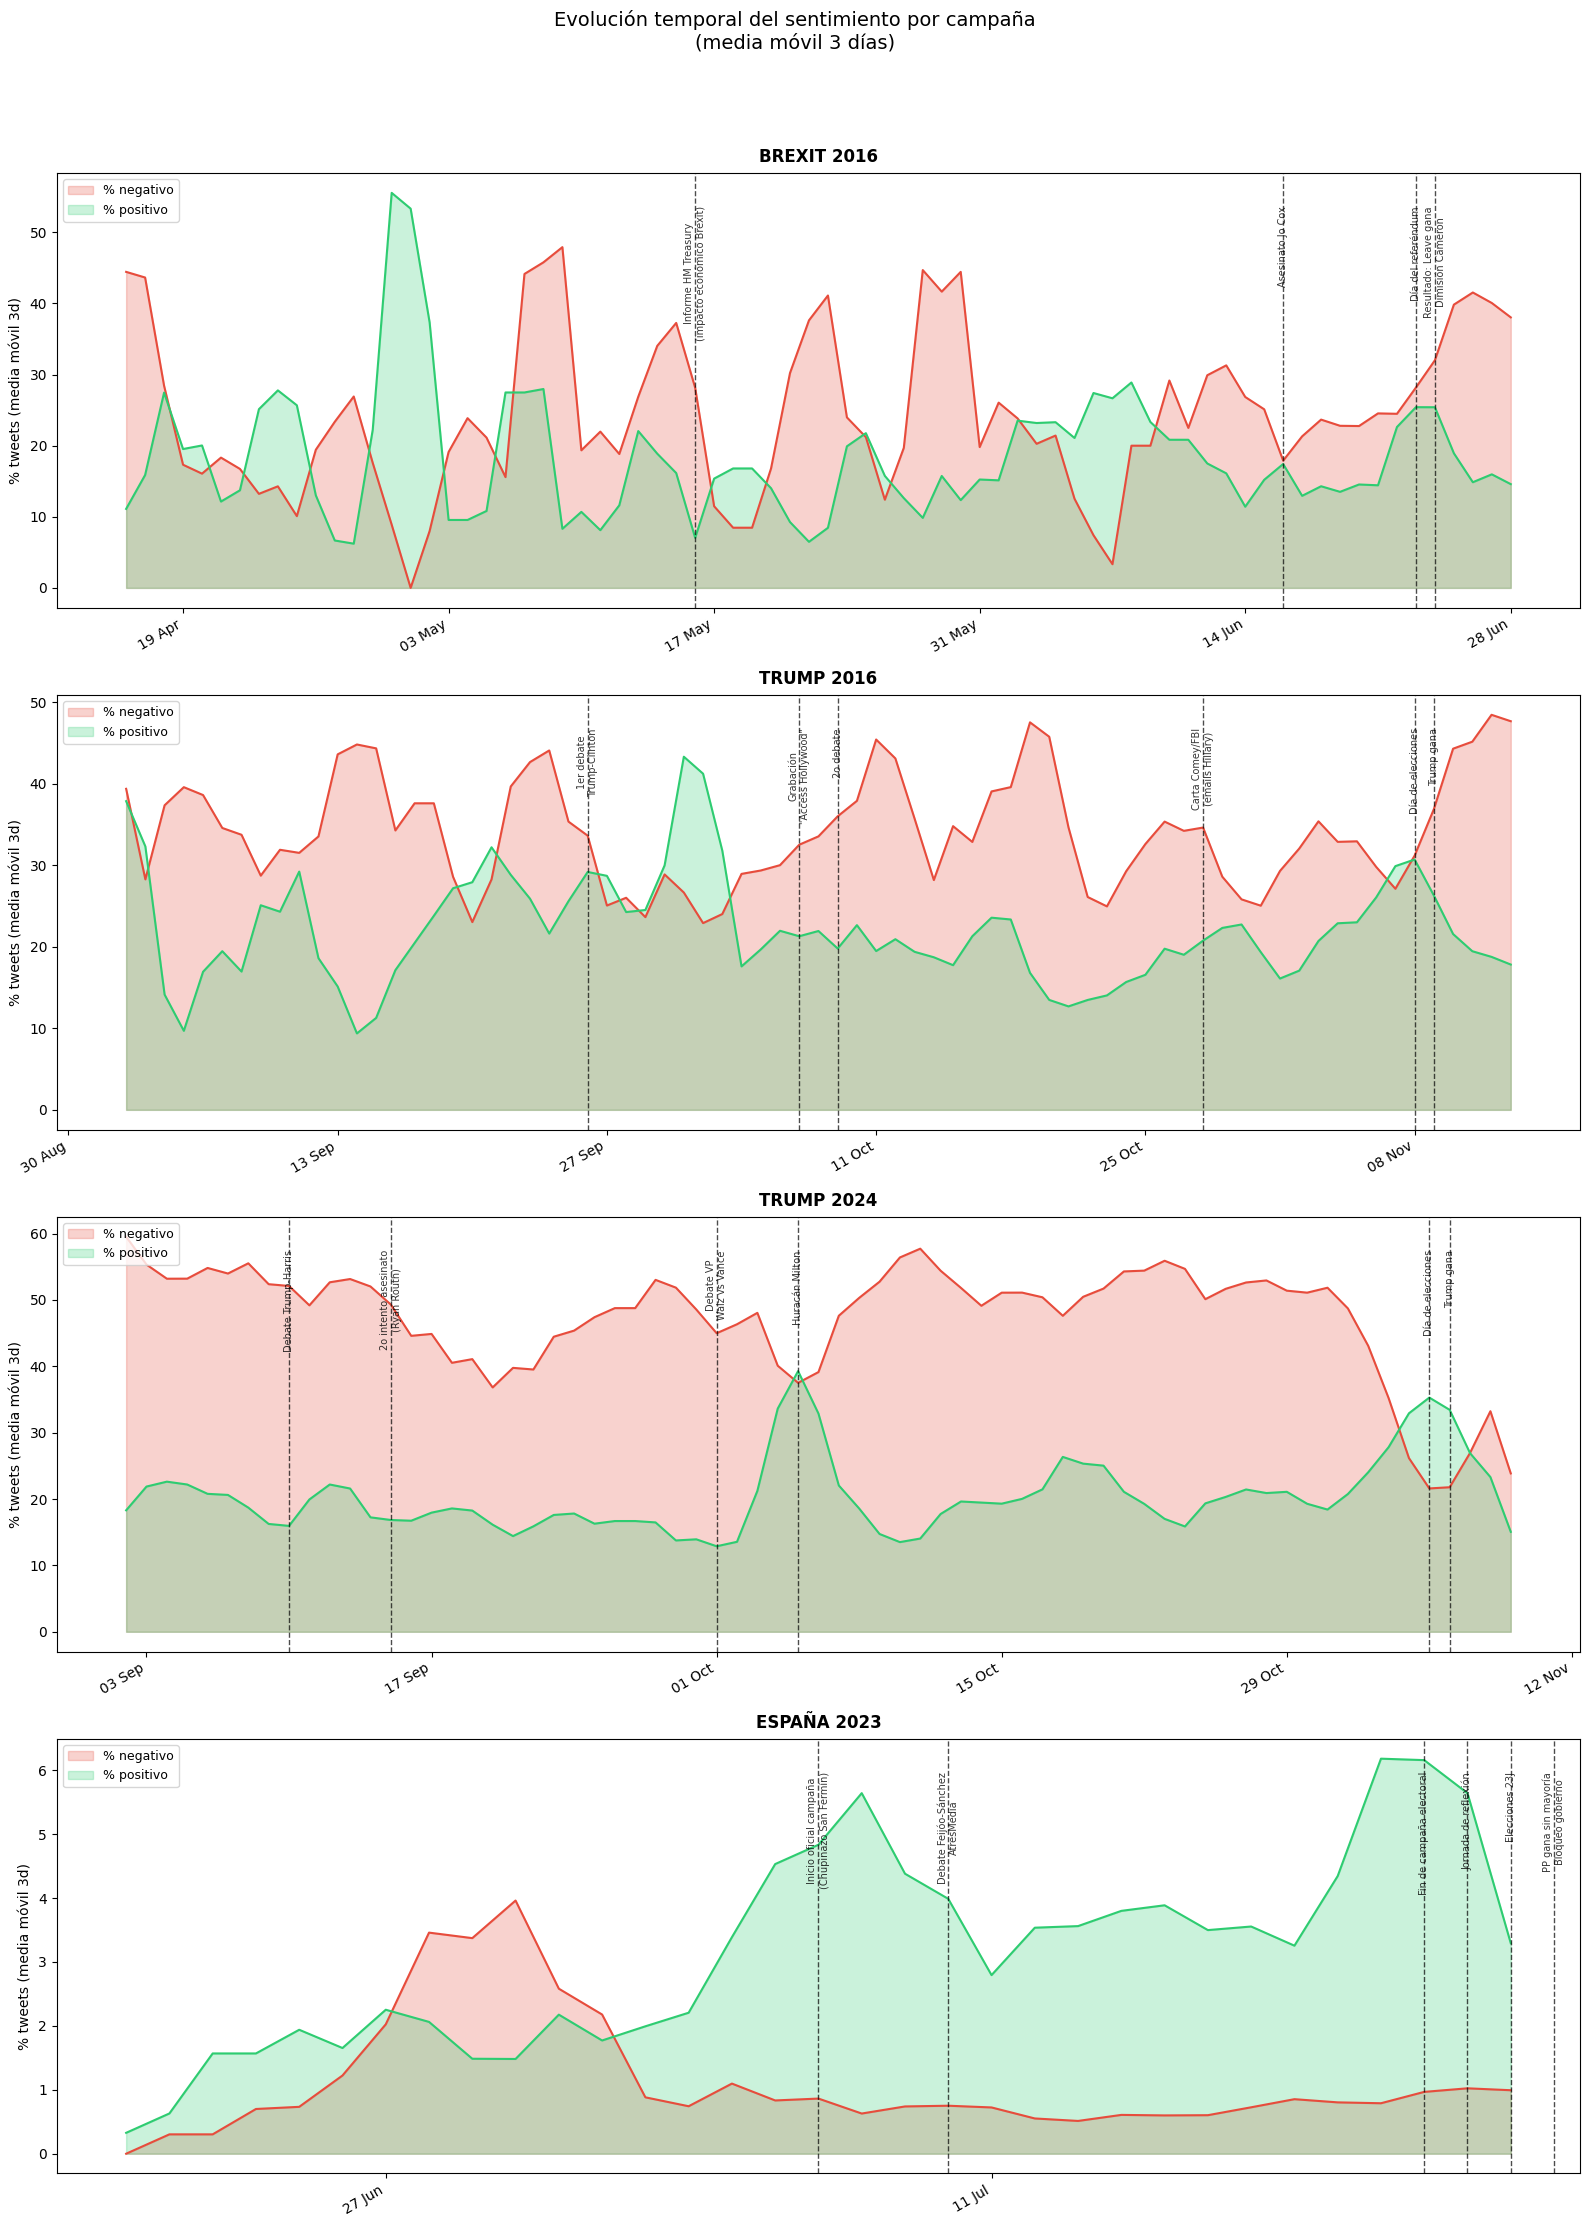

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(16, 22))

for ax, (campaign, df) in zip(axes, dfs.items()):
    daily = df.groupby('date').agg(
        polarity_mean=('polarity', 'mean'),
        n_tweets=('polarity', 'count'),
        pct_neg=('sentiment', lambda x: (x == 'negativo').mean() * 100),
        pct_pos=('sentiment', lambda x: (x == 'positivo').mean() * 100),
    ).reset_index()
    daily['date']          = pd.to_datetime(daily['date'])
    daily['rolling_pol']   = daily['polarity_mean'].rolling(3, center=True).mean()
    daily['rolling_neg']   = daily['pct_neg'].rolling(3, center=True).mean()
    daily['rolling_pos']   = daily['pct_pos'].rolling(3, center=True).mean()

    ax.fill_between(daily['date'], daily['rolling_neg'], alpha=0.25, color='#e74c3c', label='% negativo')
    ax.fill_between(daily['date'], daily['rolling_pos'], alpha=0.25, color='#2ecc71', label='% positivo')
    ax.plot(daily['date'], daily['rolling_neg'], color='#e74c3c', lw=1.5)
    ax.plot(daily['date'], daily['rolling_pos'], color='#2ecc71', lw=1.5)
    ax.set_ylabel('% tweets (media móvil 3d)')
    ax.set_title(f'{campaign.replace("_", " ").upper()}', fontsize=12, fontweight='bold', pad=8)
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Anotaciones de eventos
    for event_date, label in KEY_EVENTS.get(campaign, []):
        ed = pd.Timestamp(event_date)
        if daily['date'].min() <= ed <= daily['date'].max():
            ax.axvline(ed, color='black', linestyle='--', lw=1, alpha=0.7)
            ymax = ax.get_ylim()[1]
            ax.text(ed, ymax * 0.92, label, fontsize=7, ha='center',
                    va='top', rotation=90, color='black', alpha=0.8)

plt.suptitle('Evolución temporal del sentimiento por campaña\n(media móvil 3 días)', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('figures/03_sentiment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ¿Los tweets negativos son más virales?

Hipótesis: el contenido negativo genera más engagement (sesgo de negatividad).

/tmp/ipykernel_1821/3783063847.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp    = ax.boxplot(data, labels=order, patch_artist=True,
/tmp/ipykernel_1821/3783063847.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp    = ax.boxplot(data, labels=order, patch_artist=True,
/tmp/ipykernel_1821/3783063847.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp    = ax.boxplot(data, labels=order, patch_artist=True,
/tmp/ipykernel_1821/3783063847.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped i

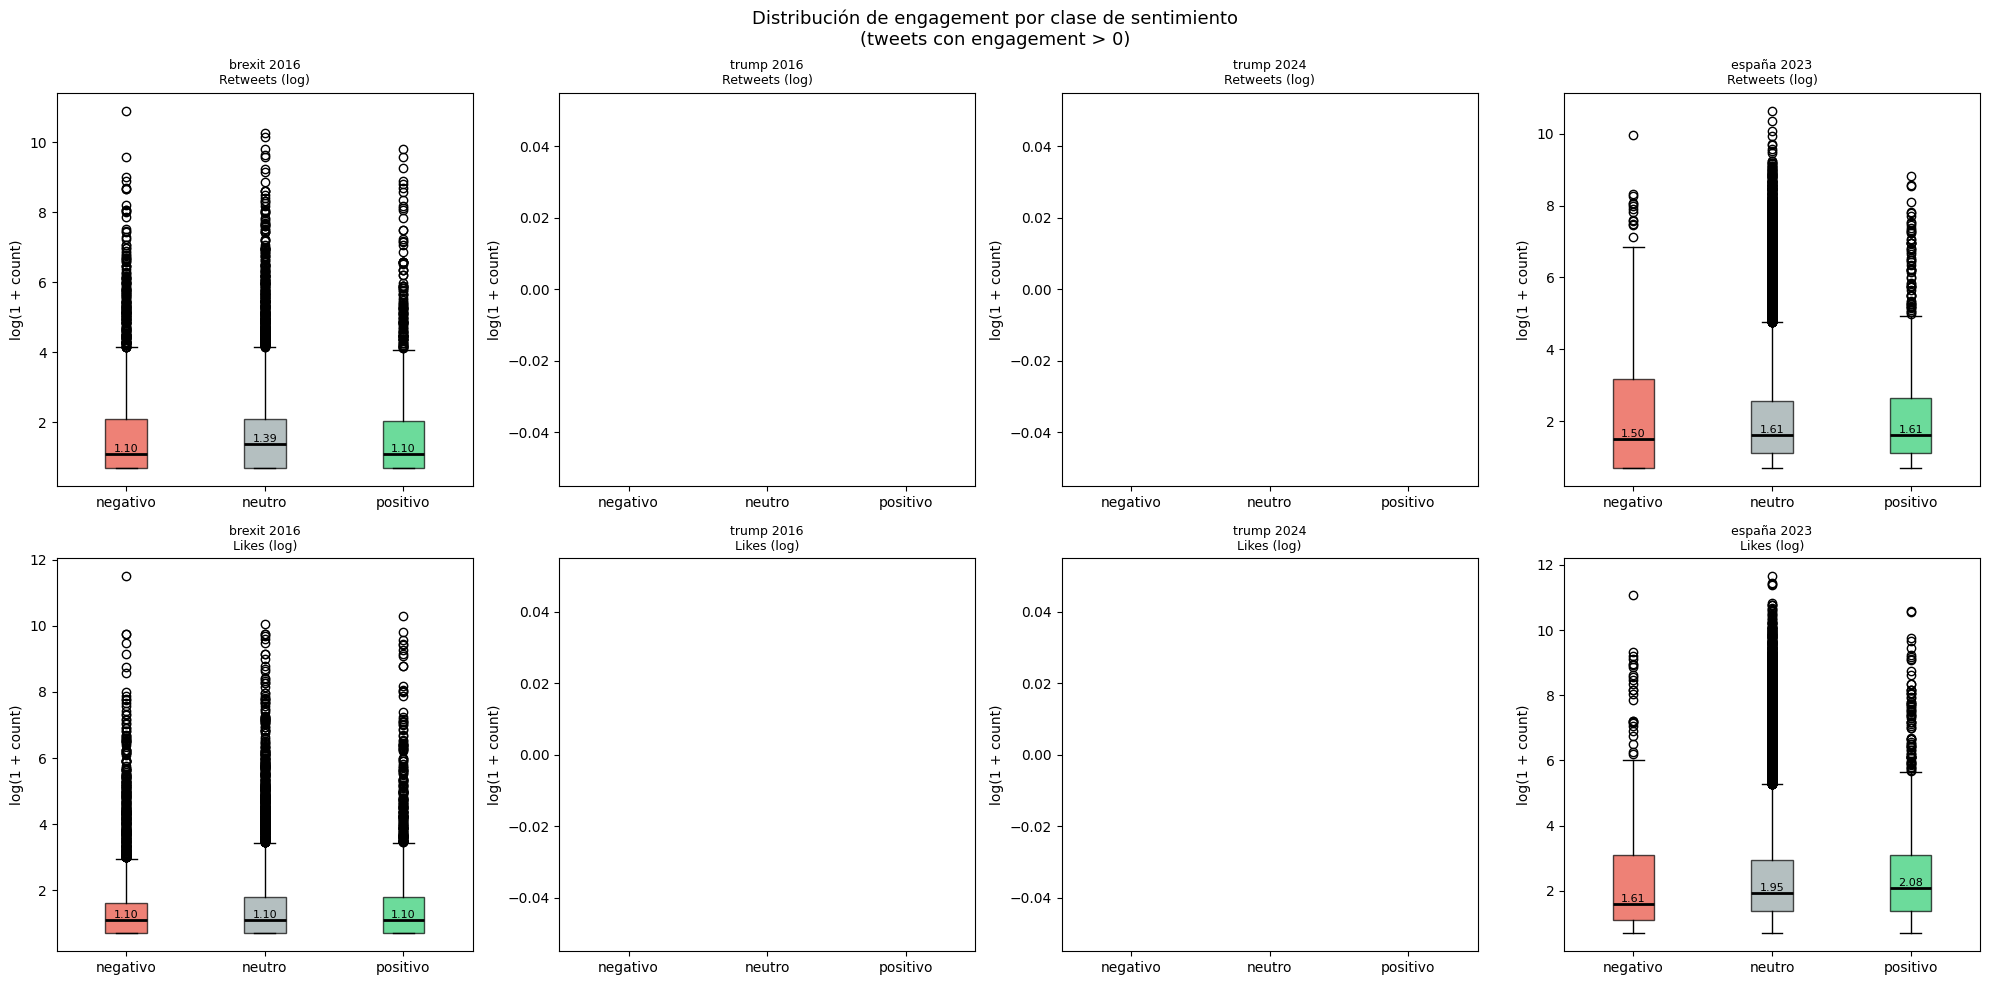


Mediana de retweets por sentimiento:
  brexit_2016: {'negativo': 1.0, 'neutro': 1.0, 'positivo': 1.0}
  trump_2016: {'negativo': nan, 'neutro': nan, 'positivo': nan}
  trump_2024: {'negativo': nan, 'neutro': nan, 'positivo': nan}
  españa_2023: {'negativo': 1.0, 'neutro': 2.0, 'positivo': 2.0}


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col_ax, (campaign, df) in enumerate(dfs.items()):
    for row_ax, metric in enumerate(['retweet_count', 'like_count']):
        if metric not in df.columns:
            continue
        ax   = axes[row_ax][col_ax]
        # Log-transform para visualizar (muchos tweets tienen 0)
        df_v = df[df[metric] > 0].copy()
        df_v['log_metric'] = np.log1p(df_v[metric])

        order = ['negativo', 'neutro', 'positivo']
        data  = [df_v[df_v['sentiment'] == s]['log_metric'].dropna() for s in order]
        bp    = ax.boxplot(data, labels=order, patch_artist=True,
                           medianprops={'color': 'black', 'lw': 2})
        for patch, color in zip(bp['boxes'], [COLORS[s] for s in order]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        metric_name = 'Retweets' if metric == 'retweet_count' else 'Likes'
        ax.set_title(f'{campaign.replace("_"," ")}\n{metric_name} (log)', fontsize=9)
        ax.set_ylabel('log(1 + count)')

        # Medias por clase
        medias = df_v.groupby('sentiment')['log_metric'].median()
        for i, s in enumerate(order):
            if s in medias:
                ax.text(i+1, medias[s], f'{medias[s]:.2f}', ha='center',
                        va='bottom', fontsize=8, color='black')

plt.suptitle('Distribución de engagement por clase de sentimiento\n(tweets con engagement > 0)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/03_virality_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de medias
print('\nMediana de retweets por sentimiento:')
for campaign, df in dfs.items():
    if 'retweet_count' not in df.columns:
        continue
    med = df.groupby('sentiment')['retweet_count'].median().round(1)
    print(f'  {campaign}: {med.to_dict()}')

## 7. Tweets más virales por sentimiento y campaña

In [11]:
for campaign, df in dfs.items():
    print(f'\n{'='*60}')
    print(f'CAMPAÑA: {campaign.upper()}')
    print(f'{'='*60}')
    for sentiment in ['positivo', 'negativo']:
        rt_col = 'retweet_count' if 'retweet_count' in df.columns else 'like_count'
        subset = df[df['sentiment'] == sentiment].nlargest(3, rt_col)
        print(f'\n  TOP 3 {sentiment.upper()} (por {rt_col}):')
        for _, row in subset.iterrows():
            txt = str(row['text'])[:150].replace('\n', ' ')
            print(f'    [{row[rt_col]:,} RT | conf={row["sentiment_score"]:.2f}] {txt}')


CAMPAÑA: BREXIT_2016

  TOP 3 POSITIVO (por retweet_count):
    [18,006.0 RT | conf=0.90] Absolutely brilliant poll on Brexit by @YouGov https://t.co/EPevG1MOAW
    [14,265.0 RT | conf=0.88] Surprise surprise, the backtracks begin.  #eurefresult https://t.co/KUMYqS6xih
    [10,471.0 RT | conf=0.55] Just arrived in Scotland. Place is going wild over the vote. They took their country back, just like we will take America back. No games!

  TOP 3 NEGATIVO (por retweet_count):
    [54,206.0 RT | conf=0.93] I can't get my head around what's happening in Britain.I'm so sorry to the youth of Britain. I fear you've been let down today x
    [14,451.0 RT | conf=0.63] Wake up. We do not have to do this. We can stop this madness through a vote in Parliament. My statement below https://t.co/V8f9Yo1TZd
    [8,175.0 RT | conf=0.63] Is Pogba the world's most overrated player?

CAMPAÑA: TRUMP_2016

  TOP 3 POSITIVO (por retweet_count):
    [nan RT | conf=0.67] Every dollar makes a difference in the Fi

## 8. Comparativa entre campañas: polarización y negatividad

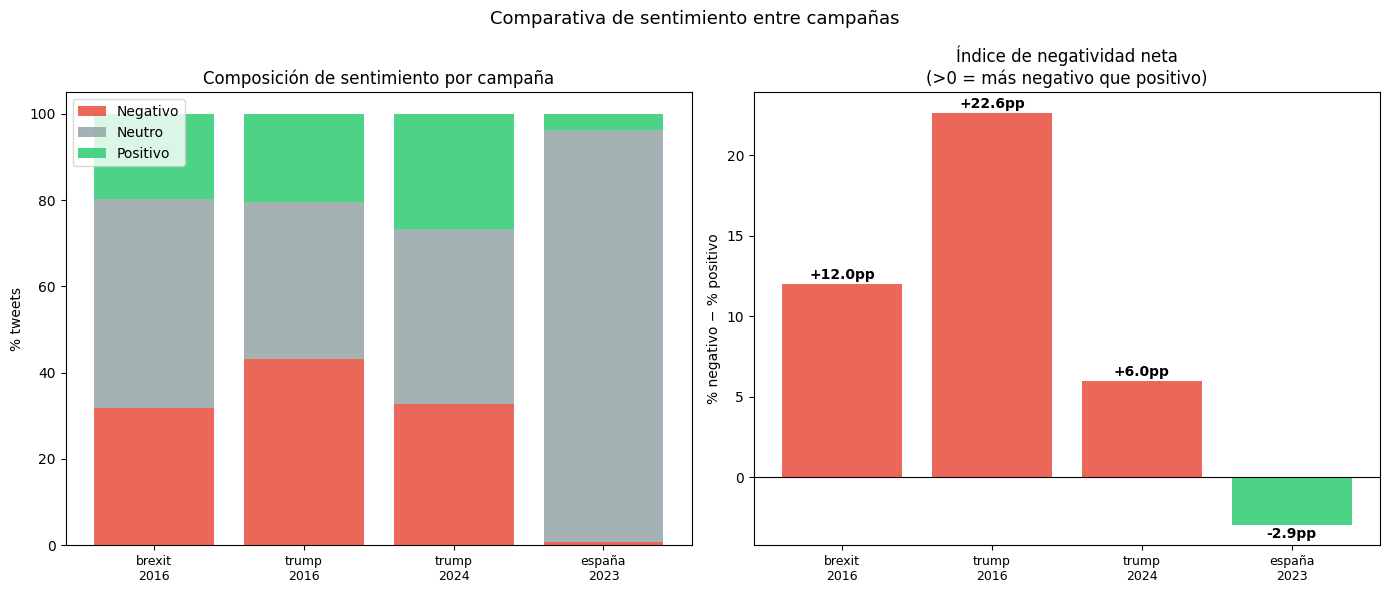

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Composición de sentimiento apilada
ax = axes[0]
camp_labels = [c.replace('_', '\n') for c in CAMPAIGNS]
neg_pct = [dfs[c]['sentiment'].eq('negativo').mean()*100 for c in CAMPAIGNS]
neu_pct = [dfs[c]['sentiment'].eq('neutro').mean()*100   for c in CAMPAIGNS]
pos_pct = [dfs[c]['sentiment'].eq('positivo').mean()*100 for c in CAMPAIGNS]

x = np.arange(len(CAMPAIGNS))
ax.bar(x, neg_pct, label='Negativo', color='#e74c3c', alpha=0.85)
ax.bar(x, neu_pct, bottom=neg_pct, label='Neutro', color='#95a5a6', alpha=0.85)
ax.bar(x, pos_pct, bottom=[n+e for n,e in zip(neg_pct, neu_pct)], label='Positivo', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(camp_labels, fontsize=9)
ax.set_ylabel('% tweets'); ax.set_title('Composición de sentimiento por campaña')
ax.legend()

# Índice de polarización: % negativo - % positivo
ax2 = axes[1]
polarity_idx = [n - p for n, p in zip(neg_pct, pos_pct)]
colors_bar   = ['#e74c3c' if v > 0 else '#2ecc71' for v in polarity_idx]
bars = ax2.bar(x, polarity_idx, color=colors_bar, alpha=0.85)
for bar, v in zip(bars, polarity_idx):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.3 if v >= 0 else -0.8),
             f'{v:+.1f}pp', ha='center', fontsize=10, fontweight='bold')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(camp_labels, fontsize=9)
ax2.set_ylabel('% negativo − % positivo')
ax2.set_title('Índice de negatividad neta\n(>0 = más negativo que positivo)')

plt.suptitle('Comparativa de sentimiento entre campañas', fontsize=13)
plt.tight_layout()
plt.savefig('figures/03_campaign_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Picos de negatividad: ¿qué ocurrió ese día?

In [13]:
print('Días con mayor % de negatividad por campaña:\n')
for campaign, df in dfs.items():
    daily = df.groupby('date').agg(
        pct_neg=('sentiment', lambda x: (x=='negativo').mean()*100),
        n=('sentiment', 'count')
    ).reset_index()
    daily = daily[daily['n'] >= 20]  # al menos 20 tweets ese día
    top3  = daily.nlargest(3, 'pct_neg')
    print(f'{campaign}:')
    for _, row in top3.iterrows():
        # Tweets más representativos de ese día
        day_tweets = df[df['date'] == row['date']]
        most_neg   = day_tweets[day_tweets['sentiment'] == 'negativo'].nlargest(1, 'sentiment_score')
        sample_txt = str(most_neg['text'].iloc[0])[:120] if len(most_neg) else ''
        print(f'  {row["date"]}: {row["pct_neg"]:.1f}% negativos ({row["n"]} tweets)')
        print(f'    → "{sample_txt}"')
    print()

Días con mayor % de negatividad por campaña:

brexit_2016:
  2016-06-27: 43.0% negativos (1004 tweets)
    → "#LeaveEU has shown how disgustingly racist and bigoted we are. Telling people to leave because they aren't white? Absolu"
  2016-06-25: 40.9% negativos (1085 tweets)
    → "Fucking fucks! #voteleave https://t.co/EAmdblOu1C"
  2016-06-26: 40.7% negativos (612 tweets)
    → "old people and stupid  racist people thank you for fucking up our generations, we will face the impact of the #LeaveEU"

trump_2016:
  2016-09-14: 73.1% negativos (52 tweets)
    → "Hillary Clinton said to "HATE" Obama and was so sick she could barely walk up to her speech #DNCleak https://t.co/0dGLXK"
  2016-10-19: 57.1% negativos (28 tweets)
    → "This is not nice, and not how a president should treat people. A president should be a role model. If I could vote I'd b"
  2016-10-16: 55.6% negativos (27 tweets)
    → "WTF!And she'd take these drugs to what... talk? to look at your dumb fuck of a mug? #ImwithH

## 10. Tweets más representativos (alta confianza por clase)

In [14]:
for campaign, df in dfs.items():
    print(f'\n{"="*60}')
    print(f'{campaign.upper()}')
    print(f'{"="*60}')
    for sent in ['positivo', 'negativo']:
        subset = df[df['sentiment'] == sent].nlargest(2, 'sentiment_score')
        print(f'\n  {sent.upper()} (más confianza):')
        for _, row in subset.iterrows():
            print(f'    [conf={row["sentiment_score"]:.3f}] {str(row["text"])[:160]}')


BREXIT_2016

  POSITIVO (más confianza):
    [conf=0.993] Love New York❤️🇺🇸 but time to head home🇬🇧.Thank you @British_Airways for the awesome upgrade. Delighted #StrongerIn https://t.co/5V7sLdjhhf
    [conf=0.993] @pettysivan We are so glad that you enjoyed yourself! Thank you again for your #TakeControl story!

  NEGATIVO (más confianza):
    [conf=0.981] Omg I quite dislike this country right now! Is no-one allowed to have an opinion without someone spouting shit! #VoteRemain #theendisnigh
    [conf=0.979] @BorisJohnson and @nigelfarage - you 2 imbeciles have fucked us over. Idiots and liars #voteremain https://t.co/9PhyooCLPd

TRUMP_2016

  POSITIVO (más confianza):
    [conf=0.993] Happy Birthday!! @C_Davis_3 Have a great day!! #MakeAmericaGreatAgain 🇺🇸🇺🇸 https://t.co/j4BtVspQui
    [conf=0.993] I am so excited for the next few years of growth and expansion under President @realDonaldTrump. #MakeAmericaGreatAgain #TrumpPence2016

  NEGATIVO (más confianza):
    [conf=0.983] #Hill

## 11. Volumen de tweets y negatividad: ¿los picos de actividad son negativos?

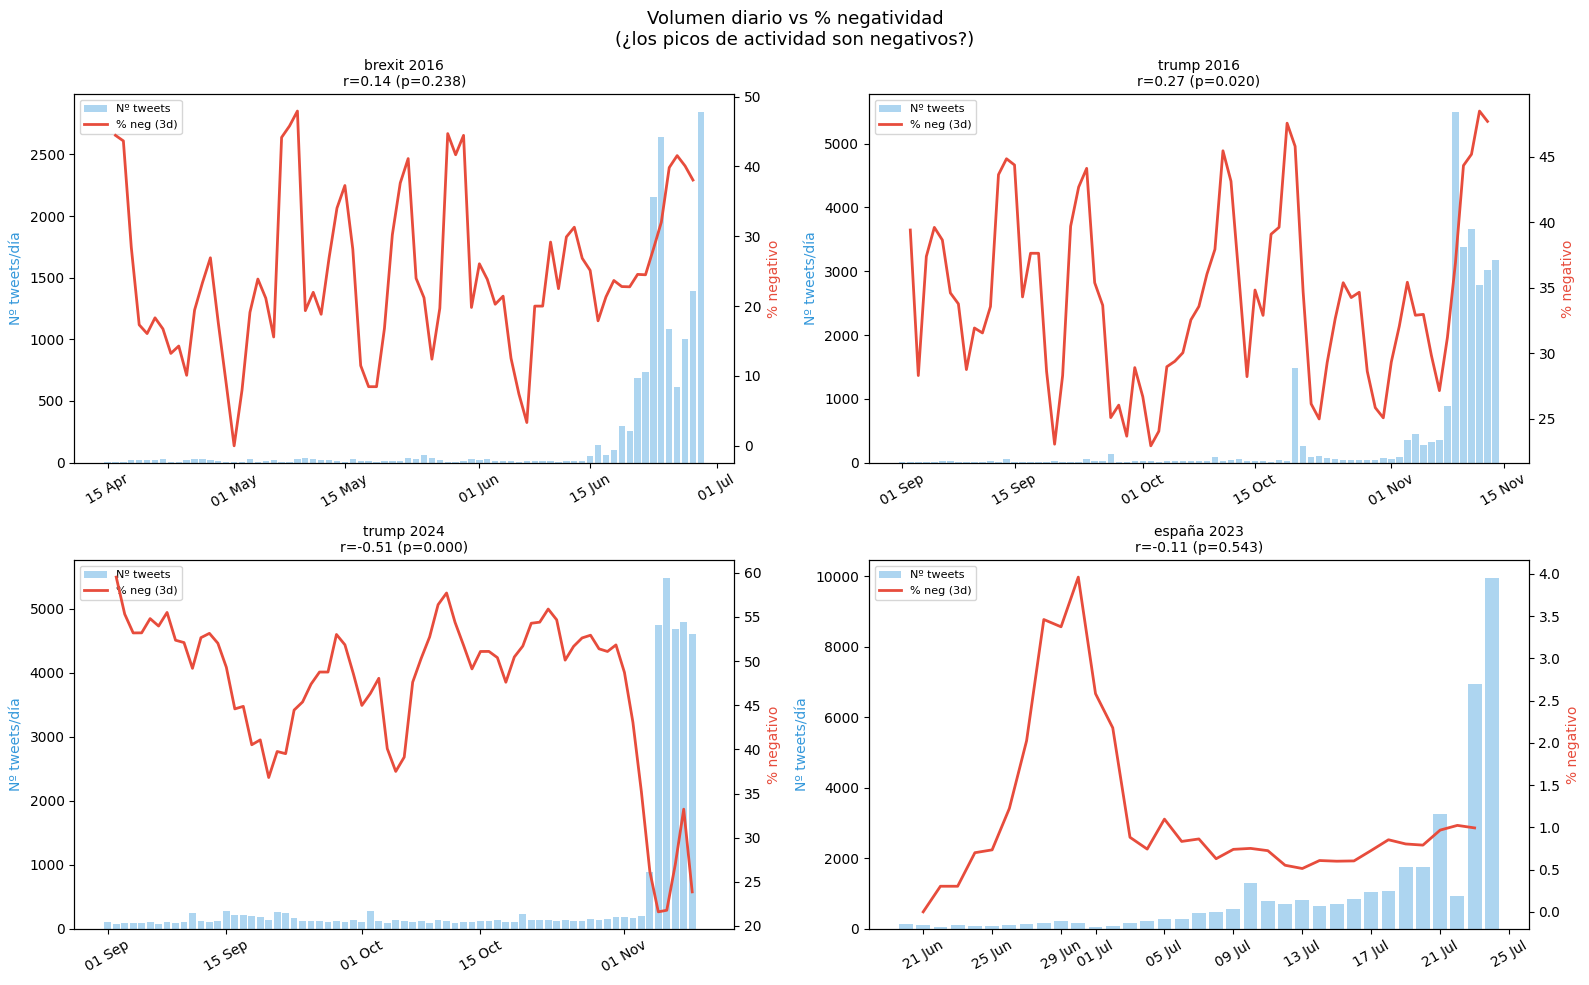

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (campaign, df) in zip(axes, dfs.items()):
    daily = df.groupby('date').agg(
        n_tweets=('sentiment', 'count'),
        pct_neg=('sentiment', lambda x: (x=='negativo').mean()*100)
    ).reset_index()
    daily['date'] = pd.to_datetime(daily['date'])

    ax2 = ax.twinx()
    ax.bar(daily['date'], daily['n_tweets'], color='#3498db', alpha=0.4, label='Nº tweets')
    ax2.plot(daily['date'], daily['pct_neg'].rolling(3, center=True).mean(),
             color='#e74c3c', lw=2, label='% neg (3d)')

    corr, p = pearsonr(daily['n_tweets'], daily['pct_neg'])
    ax.set_title(f'{campaign.replace("_"," ")}\nr={corr:.2f} (p={p:.3f})', fontsize=10)
    ax.set_ylabel('Nº tweets/día', color='#3498db')
    ax2.set_ylabel('% negativo', color='#e74c3c')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Volumen diario vs % negatividad\n(¿los picos de actividad son negativos?)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/03_volume_vs_negativity.png', dpi=150, bbox_inches='tight')
plt.show()